# Multiplex Classification Comparison (KPC / NDM / VIM)

In [1]:
import os, sys, re, string
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(os.path.dirname(_nb))))
except Exception as e:
    print(f"Could not change directory: {e}")

%load_ext autoreload
%autoreload 2
import config

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

CWD: /vol/bitbucket/gk225/POC_DDM/main_code


In [2]:
DATA_ROOT_ML  = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_Multiplex')
DATA_ROOT_DDM = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper')
DS1_NAME = '02_ACA_qdPCR_balanced'
DS2_NAME = '12_ACA_qdPCR_multiplex_balanced'
DS1_PATH = DATA_ROOT_ML / DS1_NAME

TARGET_NAMES = ['KPC', 'NDM', 'VIM']
LABEL_REMAP  = {'KPC_NDM': 'NDM_KPC', 'KPC_VIM': 'VIM_KPC', 'KPC_NDM_VIM': 'NDM_VIM_KPC'}
LABEL_ORDER  = ['NDM', 'VIM', 'KPC', 'NDM_VIM', 'NDM_KPC', 'VIM_KPC', 'NDM_VIM_KPC']
CM_LABELS = LABEL_ORDER + ['empty']
CM_DISP   = [l.replace('_', '+') if l != 'empty' else '\u2205' for l in CM_LABELS]

DS2_BIN_MAP = np.array([
    [1,0,0],[0,1,0],[1,1,0],[0,0,1],[1,0,1],[0,1,1],[1,1,1]
])

ML_TRAINING_DATA_PATH = 'curve_for_training_ml.joblib'

print(f'DS1 ({DS1_NAME}) -> {DS1_PATH}')
print(f'DS2 ({DS2_NAME}) -> {DATA_ROOT_DDM / DS2_NAME}')
print(f'multiplex training data filename: {ML_TRAINING_DATA_PATH}')

DS1 (02_ACA_qdPCR_balanced) -> /vol/bitbucket/gk225/POC_DDM_datasets/LAB_Multiplex/02_ACA_qdPCR_balanced
DS2 (12_ACA_qdPCR_multiplex_balanced) -> /vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper/12_ACA_qdPCR_multiplex_balanced
multiplex training data filename: curve_for_training_ml.joblib


## 1. Data profile

In [3]:
ds1_train = joblib.load(DS1_PATH / ML_TRAINING_DATA_PATH)

X_curves_ds1   = ds1_train['curves']['ori_curves']
y_binary_ds1   = ds1_train['label_binarized']
all_targets_ds1 = ds1_train['all_targets']
conc_ds1       = np.asarray(ds1_train['concentration'])
T_ds1          = X_curves_ds1.shape[1]

assert list(all_targets_ds1) == TARGET_NAMES, all_targets_ds1
print(f'N={len(X_curves_ds1):,}  T={T_ds1} cycles  targets={list(all_targets_ds1)}')
print(f'Concentration levels: {sorted(np.unique(conc_ds1).tolist())}')

N=10,383  T=45 cycles  targets=['KPC', 'NDM', 'VIM']
Concentration levels: [10000.0]


In [4]:
def _bin_to_label(vec):
    names = [TARGET_NAMES[i] for i, v in enumerate(vec) if v == 1]
    if not names:
        return 'empty'
    raw = '_'.join(sorted(names, key=TARGET_NAMES.index))
    return LABEL_REMAP.get(raw, raw)


profile_labels = np.array([_bin_to_label(row) for row in y_binary_ds1])
profile_df = pd.DataFrame({'target': profile_labels, 'concentration': conc_ds1})
profile_df = profile_df[profile_df['target'] != 'empty']

concs = sorted(profile_df['concentration'].unique())
target_rows = [l for l in LABEL_ORDER]
profile_counts = (profile_df.groupby(['target', 'concentration']).size()
                  .unstack('concentration', fill_value=0)
                  .reindex(index=target_rows, columns=concs, fill_value=0))
profile_counts.index = [l.replace('_', ' + ') for l in profile_counts.index]
profile_counts

concentration,10000.0
NDM,1643
VIM,1541
KPC,875
NDM + VIM,1535
NDM + KPC,1638
VIM + KPC,1582
NDM + VIM + KPC,1569


In [5]:
def build_data_profile_latex(counts_df, concs, caption, label):
    """Rows = target combination (already '+'-joined), columns = concentration
    (copies/reaction). Booktabs style matching RQ1_01_lab_results.ipynb's convention."""
    lines = []
    lines.append(r'\begin{table}[htbp]')
    lines.append(r'    \centering')
    lines.append(f'    \\caption{{{caption}}}')
    lines.append(f'    \\label{{{label}}}')
    lines.append(r'    \small')
    lines.append(r'    \resizebox{\textwidth}{!}{')
    lines.append(r'    \begin{tabular}{l' + 'r' * len(concs) + '}')
    lines.append(r'    \toprule')
    header = ['\\textbf{Target}'] + [f'\\textbf{{{c:,.0f}}}' for c in concs]
    lines.append('    ' + ' & '.join(header) + r' \\')
    lines.append(r'    \midrule')
    for tgt in counts_df.index:
        row_vals = [f'{int(v):,}' if v else '--' for v in counts_df.loc[tgt, concs]]
        lines.append(f'    {tgt} & ' + ' & '.join(row_vals) + r' \\')
    lines.append(r'    \midrule')
    total_row = [f'{int(counts_df[c].sum()):,}' for c in concs]
    lines.append(r'    \textbf{Total} & ' + ' & '.join(total_row) + r' \\')
    lines.append(r'    \bottomrule')
    lines.append(r'    \end{tabular}')
    lines.append('    }')
    lines.append(r'\end{table}')
    return '\n'.join(lines)


data_profile_caption = (
    "Well-level curve counts across all combinations of the three carbapenemase gene targets "
    "(KPC, NDM, VIM) in the balanced qdPCR multiplex dataset, adapted from the digital PCR panel "
    "of Moniri et al.~\\cite{paper203}, by target combination and DNA concentration "
    "(copies/reaction). Each curve spans 45 amplification cycles."
)
data_profile_latex = build_data_profile_latex(
    profile_counts, concs, data_profile_caption, 'tab:multiplex_data_profile'
)
print(data_profile_latex)

\begin{table}[htbp]
    \centering
    \caption{Well-level curve counts across all combinations of the three carbapenemase gene targets (KPC, NDM, VIM) in the balanced qdPCR multiplex dataset, adapted from the digital PCR panel of Moniri et al.~\cite{paper203}, by target combination and DNA concentration (copies/reaction). Each curve spans 45 amplification cycles.}
    \label{tab:multiplex_data_profile}
    \small
    \resizebox{\textwidth}{!}{
    \begin{tabular}{lr}
    \toprule
    \textbf{Target} & \textbf{10,000} \\
    \midrule
    NDM & 1,643 \\
    VIM & 1,541 \\
    KPC & 875 \\
    NDM + VIM & 1,535 \\
    NDM + KPC & 1,638 \\
    VIM + KPC & 1,582 \\
    NDM + VIM + KPC & 1,569 \\
    \midrule
    \textbf{Total} & 10,383 \\
    \bottomrule
    \end{tabular}
    }
\end{table}


## 2. Results

In [6]:
d1_main      = joblib.load(DS1_PATH / 'classification_performances_ml_10fold.joblib')[None]
d1_serial_ss = joblib.load(DS1_PATH / 'classification_performances_ml_source_sep_serial_10fold.joblib')[None]

d2_raw = joblib.load(DATA_ROOT_DDM / DS2_NAME / 'classification_performances_10fold.joblib')
d2 = d2_raw['Ori Curves']['Native'][None]

y_trues_d1 = [np.array(yt) for yt in d1_main['y_trues_']]
y_trues_d2 = [DS2_BIN_MAP[np.array(yt)] for yt in d2['y_trues_']]

print(f'DS1: {len(y_trues_d1)} folds, N/fold \u2248 {len(y_trues_d1[0])}')
print(f'DS2: {len(y_trues_d2)} folds, N/fold \u2248 {len(y_trues_d2[0])}')

DS1: 5 folds, N/fold ≈ 2077
DS2: 5 folds, N/fold ≈ 2077


In [7]:
def exact_acc(y_true, y_pred):
    return float(np.mean(np.all(y_true == y_pred, axis=1)))

def hamming_sc(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def strict_hamming_sc(y_true, y_pred):
    fp = np.sum((1 - y_true) * y_pred, axis=1)
    return float(np.where(fp > 0, 0.0, np.mean(y_true == y_pred, axis=1)).mean())

def jaccard_sc(y_true, y_pred):
    inter = np.sum(y_true & y_pred, axis=1).astype(float)
    union = np.sum(y_true | y_pred, axis=1).astype(float)
    return float(np.mean(np.where(union > 0, inter / union, 1.0)))

METRICS = [
    ('exact',   'Exact Accuracy', exact_acc),
    ('hamming', 'Hamming Score',  hamming_sc),
]

def compute_metrics(y_trues_bin, y_preds_bin):
    out = {}
    for name, _, fn in METRICS:
        vals = [fn(yt, yp) for yt, yp in zip(y_trues_bin, y_preds_bin)]
        out[name] = (float(np.mean(vals)), float(np.std(vals)))
    return out

In [8]:
import json

with open(DS1_PATH / 'baseline_performance.json') as f:
    bl_data = json.load(f)

def _label_to_bin(s):
    vec = np.zeros(3, dtype=int)
    for p in s.split('+'):
        vec[{'KPC': 0, 'NDM': 1, 'VIM': 2}[p]] = 1
    return vec

def _build_bl_arrays(data, bl_type):
    yt, yp = [], []
    for e in data:
        if e['type'] != bl_type or e['count'] == 0:
            continue
        yt.extend([_label_to_bin(e['real'])] * e['count'])
        yp.extend([_label_to_bin(e['predicted_class'])] * e['count'])
    return np.array(yt), np.array(yp)

yt_mca, yp_mca = _build_bl_arrays(bl_data, 'MCA')
yt_aca, yp_aca = _build_bl_arrays(bl_data, 'ACA')

metrics_mca = {name: (fn(yt_mca, yp_mca), 0.0) for name, _, fn in METRICS}
metrics_aca = {name: (fn(yt_aca, yp_aca), 0.0) for name, _, fn in METRICS}

cgd_sc0_preds = [np.array(yp) for yp in d1_main['y_preds_cnn_gru_dual_']]
cgd_sc0_metrics = compute_metrics(y_trues_d1, cgd_sc0_preds)

SS_KEY = 'serial_source_sep_active_avg_p2'
ss_preds = [np.array(yp) for yp in d1_serial_ss[f'y_preds_{SS_KEY}_']]
ss_metrics = compute_metrics(y_trues_d1, ss_preds)

ds2_sc2_preds = [DS2_BIN_MAP[np.array(yp)] for yp in d2['y_preds_AC_cnn_gru_dual_supcon2_']]
ds2_sc2_metrics = compute_metrics(y_trues_d2, ds2_sc2_preds)

compare_rows = [
    ('MCA (baseline)', metrics_mca),
    ('ACA (baseline)', metrics_aca),
    ('CNN+GRU Dual Branch \u2014 Multilabel Classification Head', cgd_sc0_metrics),
    ('Serial Encoder-Decoder \u2014 Source Separation', ss_metrics),
    ('CNN+GRU Dual Branch \u2014 Label-Consolidated Multiclass Head', ds2_sc2_metrics),
]
for name, met in compare_rows:
    m, s = met['exact']
    print(f'{name:42s} exact={m*100:6.2f}\u00b1{s*100:4.2f}')

MCA (baseline)                             exact= 40.71±0.00
ACA (baseline)                             exact= 38.10±0.00
CNN+GRU Dual Branch — Multilabel Classification Head exact= 67.76±1.33
Serial Encoder-Decoder — Source Separation exact= 62.96±0.77
CNN+GRU Dual Branch — Label-Consolidated Multiclass Head exact= 76.04±1.73


In [9]:
def build_multiplex_summary_latex(compare_rows, caption, label):
    """Booktabs LaTeX table, bold = best per metric column, matching RQ1_01's style."""
    metric_keys   = [m[0] for m in METRICS]
    metric_labels = [m[1] for m in METRICS]
    best = {mk: max(compare_rows, key=lambda r: r[1][mk][0])[0] for mk in metric_keys}

    lines = []
    lines.append(r'\begin{table}[htbp]')
    lines.append(r'    \centering')
    lines.append(f'    \\caption{{{caption}}}')
    lines.append(f'    \\label{{{label}}}')
    lines.append(r'    \small')
    lines.append(r'    \resizebox{\textwidth}{!}{')
    lines.append(r'    \begin{tabular}{l' + 'r' * len(metric_keys) + '}')
    lines.append(r'    \toprule')
    header = ['\\textbf{Method}'] + [f'\\textbf{{{ml}}}' for ml in metric_labels]
    lines.append('    ' + ' & '.join(header) + r' \\')
    lines.append(r'    \midrule')
    for name, metrics in compare_rows:
        cells = []
        for mk in metric_keys:
            mean, std = metrics[mk]
            cell = (f'{mean*100:.2f}\\% $\\pm$ {std*100:.2f}\\%'
                   if std > 0 else f'{mean*100:.2f}\\%')
            if best[mk] == name:
                cell = f'\\textbf{{{cell}}}'
            cells.append(cell)
        lines.append(f'    {name} & ' + ' & '.join(cells) + r' \\')
    lines.append(r'    \bottomrule')
    lines.append(r'    \end{tabular}')
    lines.append('    }')
    lines.append(r'\end{table}')
    return '\n'.join(lines)


results_caption = (
    "Multiplex classification comparison on the qdPCR panel of Moniri et al.~\\cite{paper203}: "
    "rule-based baselines (MCA, ACA) against a multi-label CNN+GRU classifier, the serial "
    "source-separation (\\textit{Generative}) decomposition model, and a multiclass CNN+GRU on "
    "the label-consolidated dataset. Bold marks the best result per column."
)
results_latex = build_multiplex_summary_latex(
    compare_rows, results_caption, 'tab:multiplex_comparison'
)
print(results_latex)

\begin{table}[htbp]
    \centering
    \caption{Multiplex classification comparison on the qdPCR panel of Moniri et al.~\cite{paper203}: rule-based baselines (MCA, ACA) against a multi-label CNN+GRU classifier, the serial source-separation (\textit{Generative}) decomposition model, and a multiclass CNN+GRU on the label-consolidated dataset. Bold marks the best result per column.}
    \label{tab:multiplex_comparison}
    \small
    \resizebox{\textwidth}{!}{
    \begin{tabular}{lrr}
    \toprule
    \textbf{Method} & \textbf{Exact Accuracy} & \textbf{Hamming Score} \\
    \midrule
    MCA (baseline) & 40.71\% & 75.39\% \\
    ACA (baseline) & 38.10\% & 73.05\% \\
    CNN+GRU Dual Branch — Multilabel Classification Head & 67.76\% $\pm$ 1.33\% & 85.66\% $\pm$ 0.68\% \\
    Serial Encoder-Decoder — Source Separation & 62.96\% $\pm$ 0.77\% & 84.65\% $\pm$ 0.32\% \\
    CNN+GRU Dual Branch — Label-Consolidated Multiclass Head & \textbf{76.04\% $\pm$ 1.73\%} & \textbf{87.56\% $\pm$ 0.99\%} \\

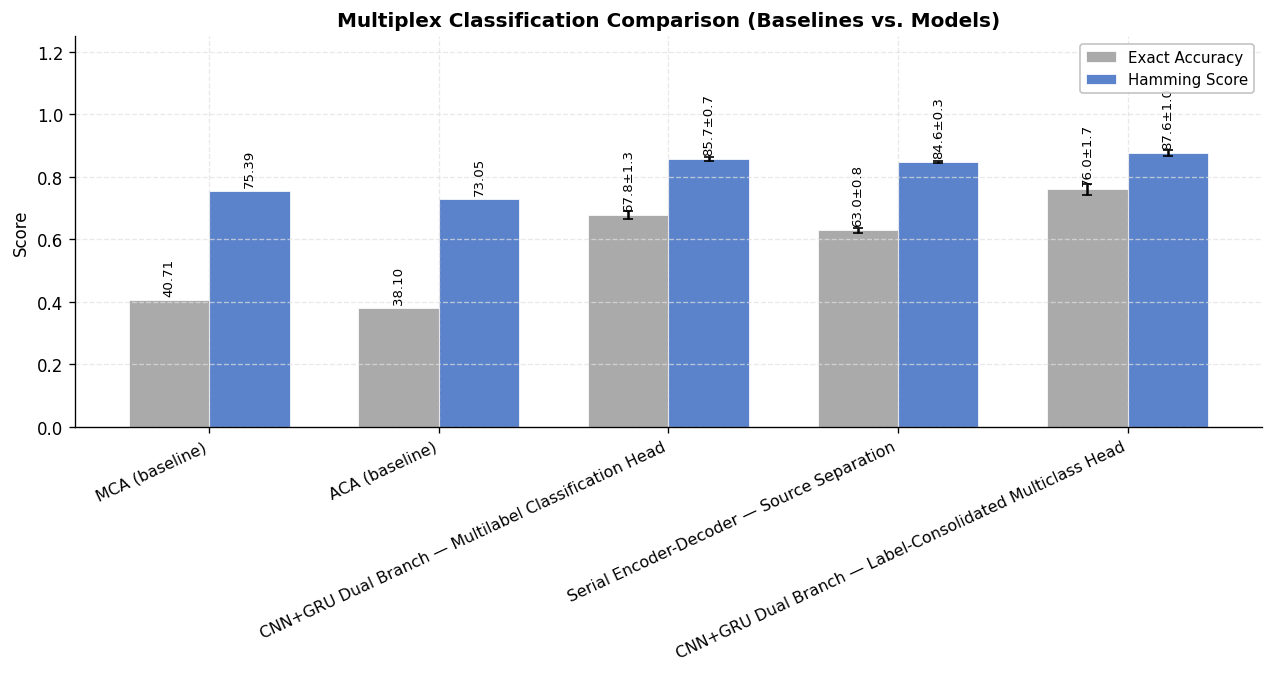

In [10]:
def plot_compare_bars(compare_rows, title):
    """Vertical grouped bars: x-axis = method (baseline/model), one group per METRICS entry."""
    names = [r[0] for r in compare_rows]
    n_methods = len(names)
    n_metrics = len(METRICS)
    x = np.arange(n_methods)
    bar_w = 0.7 / n_metrics
    colors = ['#9E9E9E', '#4472C4']

    fig, ax = plt.subplots(figsize=(1.7*n_methods + 2, 5.5), constrained_layout=True)
    for j, (mname, mlabel, _) in enumerate(METRICS):
        offset = (j - (n_metrics - 1) / 2) * bar_w
        means = [compare_rows[i][1][mname][0] for i in range(n_methods)]
        stds  = [compare_rows[i][1][mname][1] for i in range(n_methods)]
        bars = ax.bar(x + offset, means, width=bar_w,
                       yerr=[s if s > 0 else np.nan for s in stds],
                       color=colors[j % len(colors)], alpha=0.88,
                       edgecolor='white', linewidth=0.5, capsize=3, label=mlabel)
        for bar, m, s in zip(bars, means, stds):
            text = f'{m*100:.2f}' if s == 0 else f'{m*100:.1f}\u00b1{s*100:.1f}'
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                    text, ha='center', va='bottom', fontsize=8, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9.5)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_ylim(0, 1.25)
    ax.legend(fontsize=9, framealpha=0.9, edgecolor='#BDBDBD', loc='upper right')
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.show()

plot_compare_bars(compare_rows, 'Multiplex Classification Comparison (Baselines vs. Models)')


## 3. Confusion matrices

/tmp/ipykernel_2921769/633846060.py:24: RuntimeWarning: invalid value encountered in divide
  cm_n = np.where(rs > 0, cm / rs, 0.0)
/tmp/ipykernel_2921769/633846060.py:24: RuntimeWarning: invalid value encountered in divide
  cm_n = np.where(rs > 0, cm / rs, 0.0)
/tmp/ipykernel_2921769/633846060.py:24: RuntimeWarning: invalid value encountered in divide
  cm_n = np.where(rs > 0, cm / rs, 0.0)
/tmp/ipykernel_2921769/633846060.py:24: RuntimeWarning: invalid value encountered in divide
  cm_n = np.where(rs > 0, cm / rs, 0.0)
/tmp/ipykernel_2921769/633846060.py:24: RuntimeWarning: invalid value encountered in divide
  cm_n = np.where(rs > 0, cm / rs, 0.0)


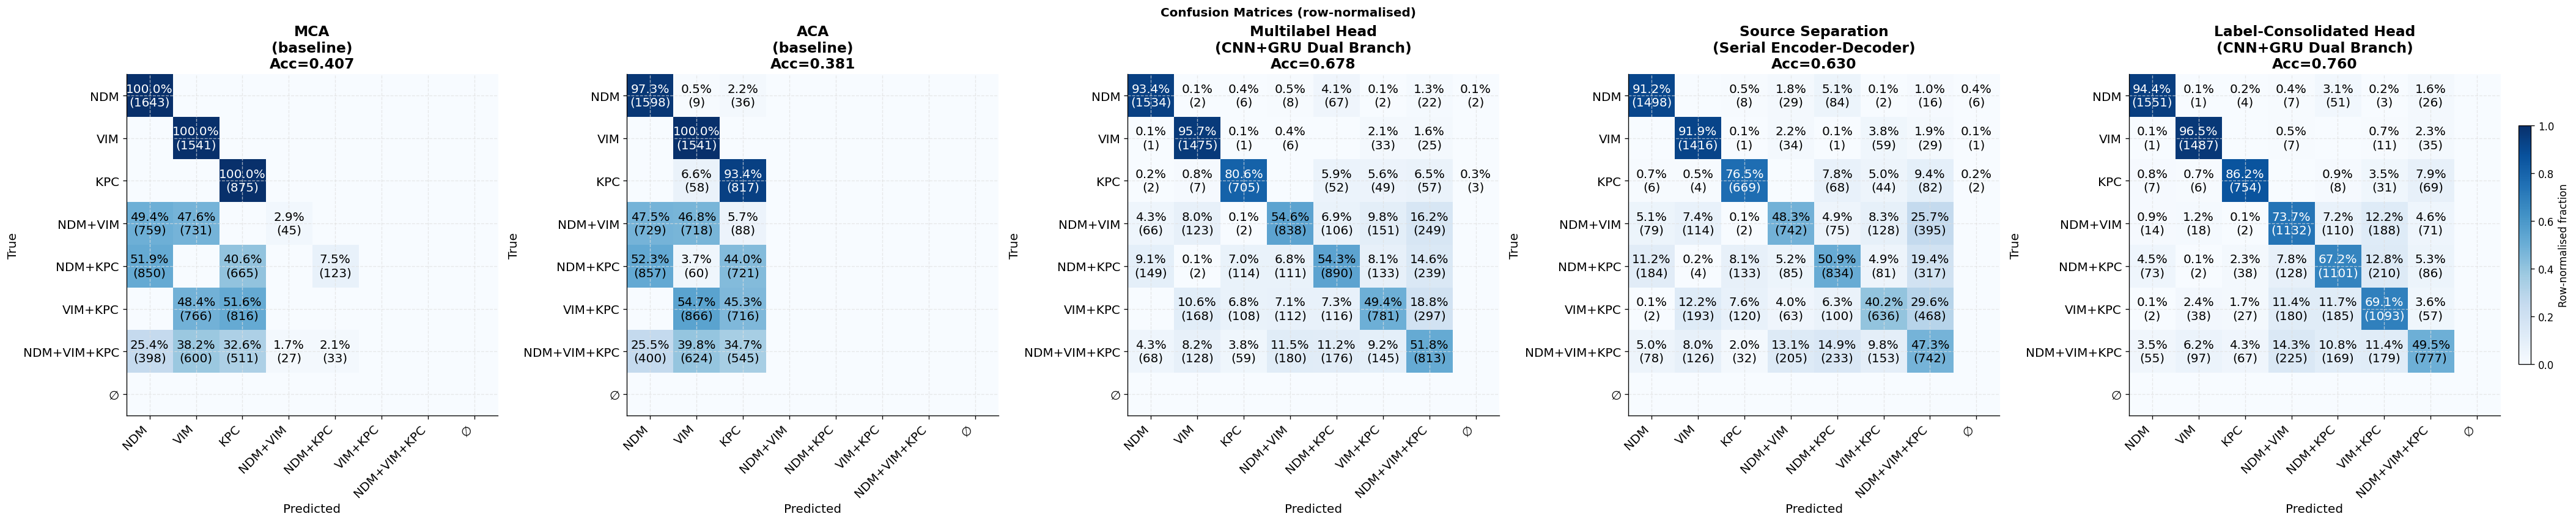

In [11]:
def _bin_to_cm_label(vec):
    targets = [TARGET_NAMES[i] for i, v in enumerate(vec) if v == 1]
    if not targets:
        return 'empty'
    raw = '_'.join(sorted(targets, key=TARGET_NAMES.index))
    return LABEL_REMAP.get(raw, raw)

def build_cm(y_true_bin, y_pred_bin):
    idx = {l: i for i, l in enumerate(CM_LABELS)}
    cm  = np.zeros((len(CM_LABELS), len(CM_LABELS)), dtype=int)
    for yt, yp in zip(y_true_bin, y_pred_bin):
        cm[idx[_bin_to_cm_label(yt)]][idx[_bin_to_cm_label(yp)]] += 1
    return cm

def plot_confusion_matrices(cms_data, sup_title):
    n_lbl = len(CM_LABELS)
    fig, axes = plt.subplots(1, len(cms_data), figsize=(7 * len(cms_data), 7),
                             constrained_layout=True)
    if len(cms_data) == 1:
        axes = [axes]
    im = None
    for ax, (title, cm) in zip(axes, cms_data):
        rs   = cm.sum(axis=1, keepdims=True)
        cm_n = np.where(rs > 0, cm / rs, 0.0)
        acc  = np.trace(cm) / cm.sum()
        im   = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1, aspect='auto')
        for r in range(n_lbl):
            for c in range(n_lbl):
                if cm[r, c] == 0:
                    continue
                fg = 'white' if cm_n[r, c] > 0.55 else 'black'
                ax.text(c, r, f'{cm_n[r,c]*100:.1f}%\n({cm[r,c]})',
                        ha='center', va='center', fontsize=12, color=fg)
        ax.set_xticks(range(n_lbl)); ax.set_xticklabels(CM_DISP, rotation=45, ha='right', fontsize=12)
        ax.set_yticks(range(n_lbl)); ax.set_yticklabels(CM_DISP, fontsize=12)
        ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
        ax.set_title(f'{title}\nAcc={acc:.3f}', fontsize=14, fontweight='bold')
    if im:
        plt.colorbar(im, ax=axes[-1], label='Row-normalised fraction', shrink=0.7)
    fig.suptitle(sup_title, fontsize=12, fontweight='bold')
    plt.show()


yt_d1_all  = np.concatenate([np.array(yt) for yt in y_trues_d1])
yp_cgd_sc0 = np.concatenate(cgd_sc0_preds)
cm_cgd_sc0 = build_cm(yt_d1_all, yp_cgd_sc0)

yp_ss_all = np.concatenate(ss_preds)
cm_ss     = build_cm(yt_d1_all, yp_ss_all)

yt_ds2_all = np.concatenate(y_trues_d2)
yp_ds2_sc2 = np.concatenate(ds2_sc2_preds)
cm_ds2_sc2 = build_cm(yt_ds2_all, yp_ds2_sc2)

cm_mca = build_cm(yt_mca, yp_mca)
cm_aca = build_cm(yt_aca, yp_aca)

plot_confusion_matrices(
    [('MCA\n(baseline)', cm_mca),
     ('ACA\n(baseline)', cm_aca),
     ('Multilabel Head\n(CNN+GRU Dual Branch)', cm_cgd_sc0),
     ('Source Separation\n(Serial Encoder-Decoder)', cm_ss),
     ('Label-Consolidated Head\n(CNN+GRU Dual Branch)', cm_ds2_sc2)],
    'Confusion Matrices (row-normalised)'
)

## 4. Source-separation decomposition visualisation ("Generative" method)

In [12]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from model_utils_source_sep import build_serial_bigger_encoder, build_parametric_decoder

VARIANT     = 'active'
AVG_CONSIST = True
D_SHARED    = 16
D_TARGET    = 10
N_EXAMPLES  = 5
N_REF_CURVES = 20
SEED        = 42

variant_key = f'{VARIANT}_avg' if AVG_CONSIST else VARIANT
enc_path    = DS1_PATH / f'source_sep_serial_{variant_key}_encoder_weights.weights.h5'
print(f'Variant: {VARIANT}  avg_consist={AVG_CONSIST}  key={variant_key}')
print(f'Encoder weights: {enc_path}  exists={enc_path.exists()}')

Variant: active  avg_consist=True  key=active_avg
Encoder weights: /vol/bitbucket/gk225/POC_DDM_datasets/LAB_Multiplex/02_ACA_qdPCR_balanced/source_sep_serial_active_avg_encoder_weights.weights.h5  exists=True


In [13]:
X_curves    = ds1_train['curves']['ori_curves'].astype(np.float32)
y_binary    = ds1_train['label_binarized'].astype(np.int32)
all_targets = ds1_train['all_targets']
T           = X_curves.shape[1]
N, n_targets = y_binary.shape

dec_paths = [DS1_PATH / f'source_sep_serial_{variant_key}_decoder_{j}_weights.weights.h5'
            for j in range(n_targets)]
missing = [p for p in [enc_path] + dec_paths if not p.exists()]
if missing:
    avg_flag = ' --avg_consist' if AVG_CONSIST else ''
    raise FileNotFoundError(
        'Missing weight files:\n' + '\n'.join(f'  {p}' for p in missing)
        + f'\n\nRun: python 03c_serial_source_sep_pretraining.py --variant {VARIANT}{avg_flag} --force_rerun --validate'
    )

tf.keras.backend.clear_session()
encoder  = build_serial_bigger_encoder(T, D_SHARED, D_TARGET, n_targets)
decoders = [build_parametric_decoder(D_SHARED, D_TARGET, T_max=T, j=j) for j in range(n_targets)]
encoder.load_weights(enc_path)
for j, dec in enumerate(decoders):
    dec.load_weights(dec_paths[j])
print(f'Loaded {enc_path.name}; encoder params={encoder.count_params():,}')

Loaded source_sep_serial_active_avg_encoder_weights.weights.h5; encoder params=47,118


In [14]:
def render_sigmoid_np(params):
    T_ = X_curves.shape[1]
    Fm = params[:, 0:1]; Fb = params[:, 1:2]
    Sc = params[:, 2:3]; Cs = params[:, 3:4]; As = params[:, 4:5]
    t  = np.arange(T_, dtype=np.float32)[np.newaxis, :]
    return Fm / (1.0 + np.exp(-Sc * (t - Cs))) ** As + Fb

X_enc    = np.expand_dims(X_curves, -1)
Z        = encoder.predict(X_enc, batch_size=512, verbose=0)
z_shared = Z[:, :D_SHARED]
z_parts  = [Z[:, D_SHARED + j*D_TARGET: D_SHARED + (j+1)*D_TARGET] for j in range(n_targets)]

dec_curves = []
for j, dec in enumerate(decoders):
    dec_in   = np.concatenate([z_shared, z_parts[j]], axis=-1).astype(np.float32)
    params_j = dec.predict(dec_in, batch_size=512, verbose=0)
    dec_curves.append(render_sigmoid_np(params_j))

active_sum = sum(y_binary[:, j:j+1] * dec_curves[j] for j in range(n_targets))
if AVG_CONSIST:
    n_active = np.maximum(y_binary.sum(axis=1, keepdims=True), 1)
    recon = active_sum / n_active
else:
    recon = active_sum

mse = np.mean((X_curves - recon) ** 2, axis=1)
print(f'Reconstruction MSE  mean={mse.mean():.5f}  median={np.median(mse):.5f}')

rng = np.random.default_rng(SEED)
ref_banks = []
for j, tgt in enumerate(all_targets):
    mask_j = (y_binary.sum(axis=1) == 1) & (y_binary[:, j] == 1)
    bank_j = X_curves[mask_j]
    idx    = rng.choice(len(bank_j), size=min(N_REF_CURVES, len(bank_j)), replace=False)
    ref_banks.append(bank_j[idx])
print('Reference banks built.')

Reconstruction MSE  mean=0.00791  median=0.00332
Reference banks built.


In [15]:
COLORS = {t: c for t, c in zip(all_targets, ['#4472C4', '#ED7D31', '#70AD47'])}
t_axis = np.arange(T)


def plot_combo(combo, n_examples=N_EXAMPLES, seed=SEED):
    combo = np.asarray(combo, dtype=np.int32)
    mask  = np.all(y_binary == combo, axis=1)
    idxs  = np.where(mask)[0]
    if len(idxs) == 0:
        print(f'No wells with combo {combo.tolist()}'); return
    rng2 = np.random.default_rng(seed)
    pick = rng2.choice(idxs, size=min(n_examples, len(idxs)), replace=False)

    active = [j for j in range(n_targets) if combo[j]]
    label  = '+'.join(all_targets[j] for j in active) or 'Negative'
    consist_label = 'avg' if AVG_CONSIST else 'sum'

    nrows, ncols = len(pick), n_targets + 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 2.8 * nrows), squeeze=False)
    fig.suptitle(f'{label}  ({len(idxs):,} wells total, showing {nrows})'
                f'  [variant={VARIANT}  consist={consist_label}]',
                fontsize=12, fontweight='bold', y=1.01)

    axes[0, 0].set_title(f'Original + active {consist_label}', fontsize=9)
    for j, tgt in enumerate(all_targets):
        suffix = '' if combo[j] else ' (absent)'
        col    = COLORS[tgt] if combo[j] else 'grey'
        axes[0, j + 1].set_title(f'{tgt}{suffix}', fontsize=9, color=col)

    for row, wi in enumerate(pick):
        ax0 = axes[row, 0]
        ax0.plot(t_axis, X_curves[wi], color='black', lw=1.5, label='Original', zorder=5)
        ax0.plot(t_axis, recon[wi], color='#C00000', lw=1.2, ls='--',
                label=f'Active {consist_label}', zorder=4)
        for j in range(n_targets):
            ax0.plot(t_axis, dec_curves[j][wi], color=COLORS[all_targets[j]], lw=0.8,
                    alpha=0.75 if combo[j] else 0.25, zorder=3)
        ax0.set_ylabel(f'well {wi}', fontsize=7)
        if row == 0:
            ax0.legend(fontsize=6, loc='upper left', framealpha=0.7)
        ax0.tick_params(labelsize=7)
        ax0.set_xticks(np.arange(0, T, 10))

        for j, tgt in enumerate(all_targets):
            ax  = axes[row, j + 1]
            col = COLORS[tgt]
            is_active = bool(combo[j])
            for rc in ref_banks[j]:
                ax.plot(t_axis, rc, color='black', lw=0.4, alpha=0.12, zorder=1)
            ax.plot(t_axis, ref_banks[j].mean(axis=0), color='black', lw=1.0, ls=':',
                    alpha=0.55, label='Ref mean', zorder=2)
            ax.plot(t_axis, dec_curves[j][wi], color=col, lw=1.5,
                    alpha=1.0 if is_active else 0.4, label='Decoded', zorder=3)
            if row == 0:
                ax.legend(fontsize=6, loc='upper left', framealpha=0.7)
            ax.tick_params(labelsize=7)
            ax.set_xticks(np.arange(0, T, 10))

    for ax in axes[-1]:
        ax.set_xlabel('Cycle', fontsize=8)
    plt.tight_layout()
    plt.show()

### KPC only

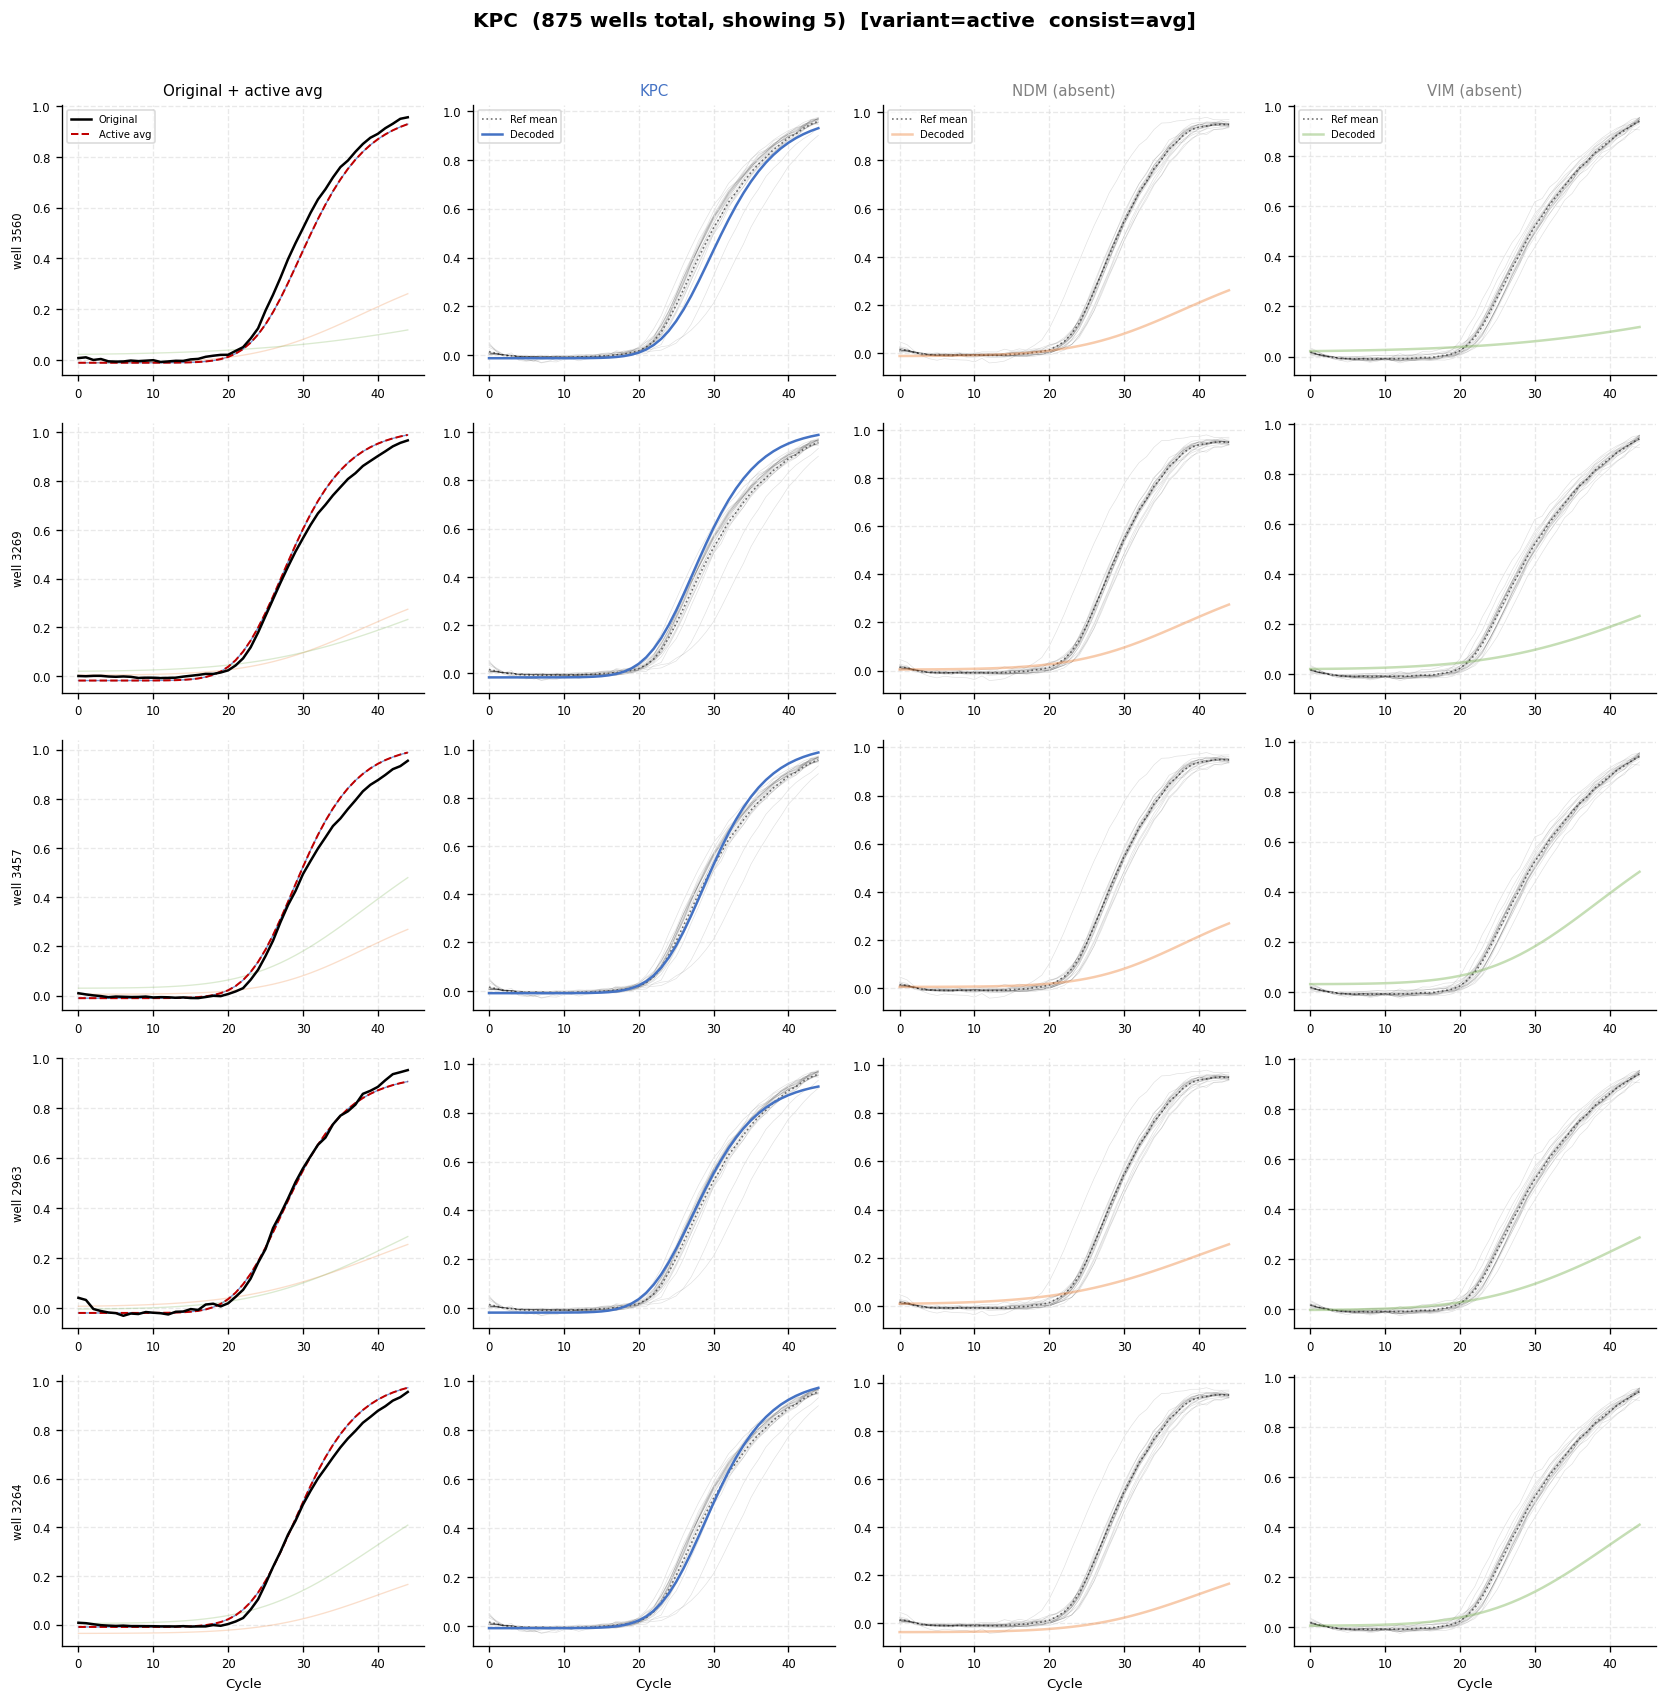

In [16]:
plot_combo([1, 0, 0])

### NDM only

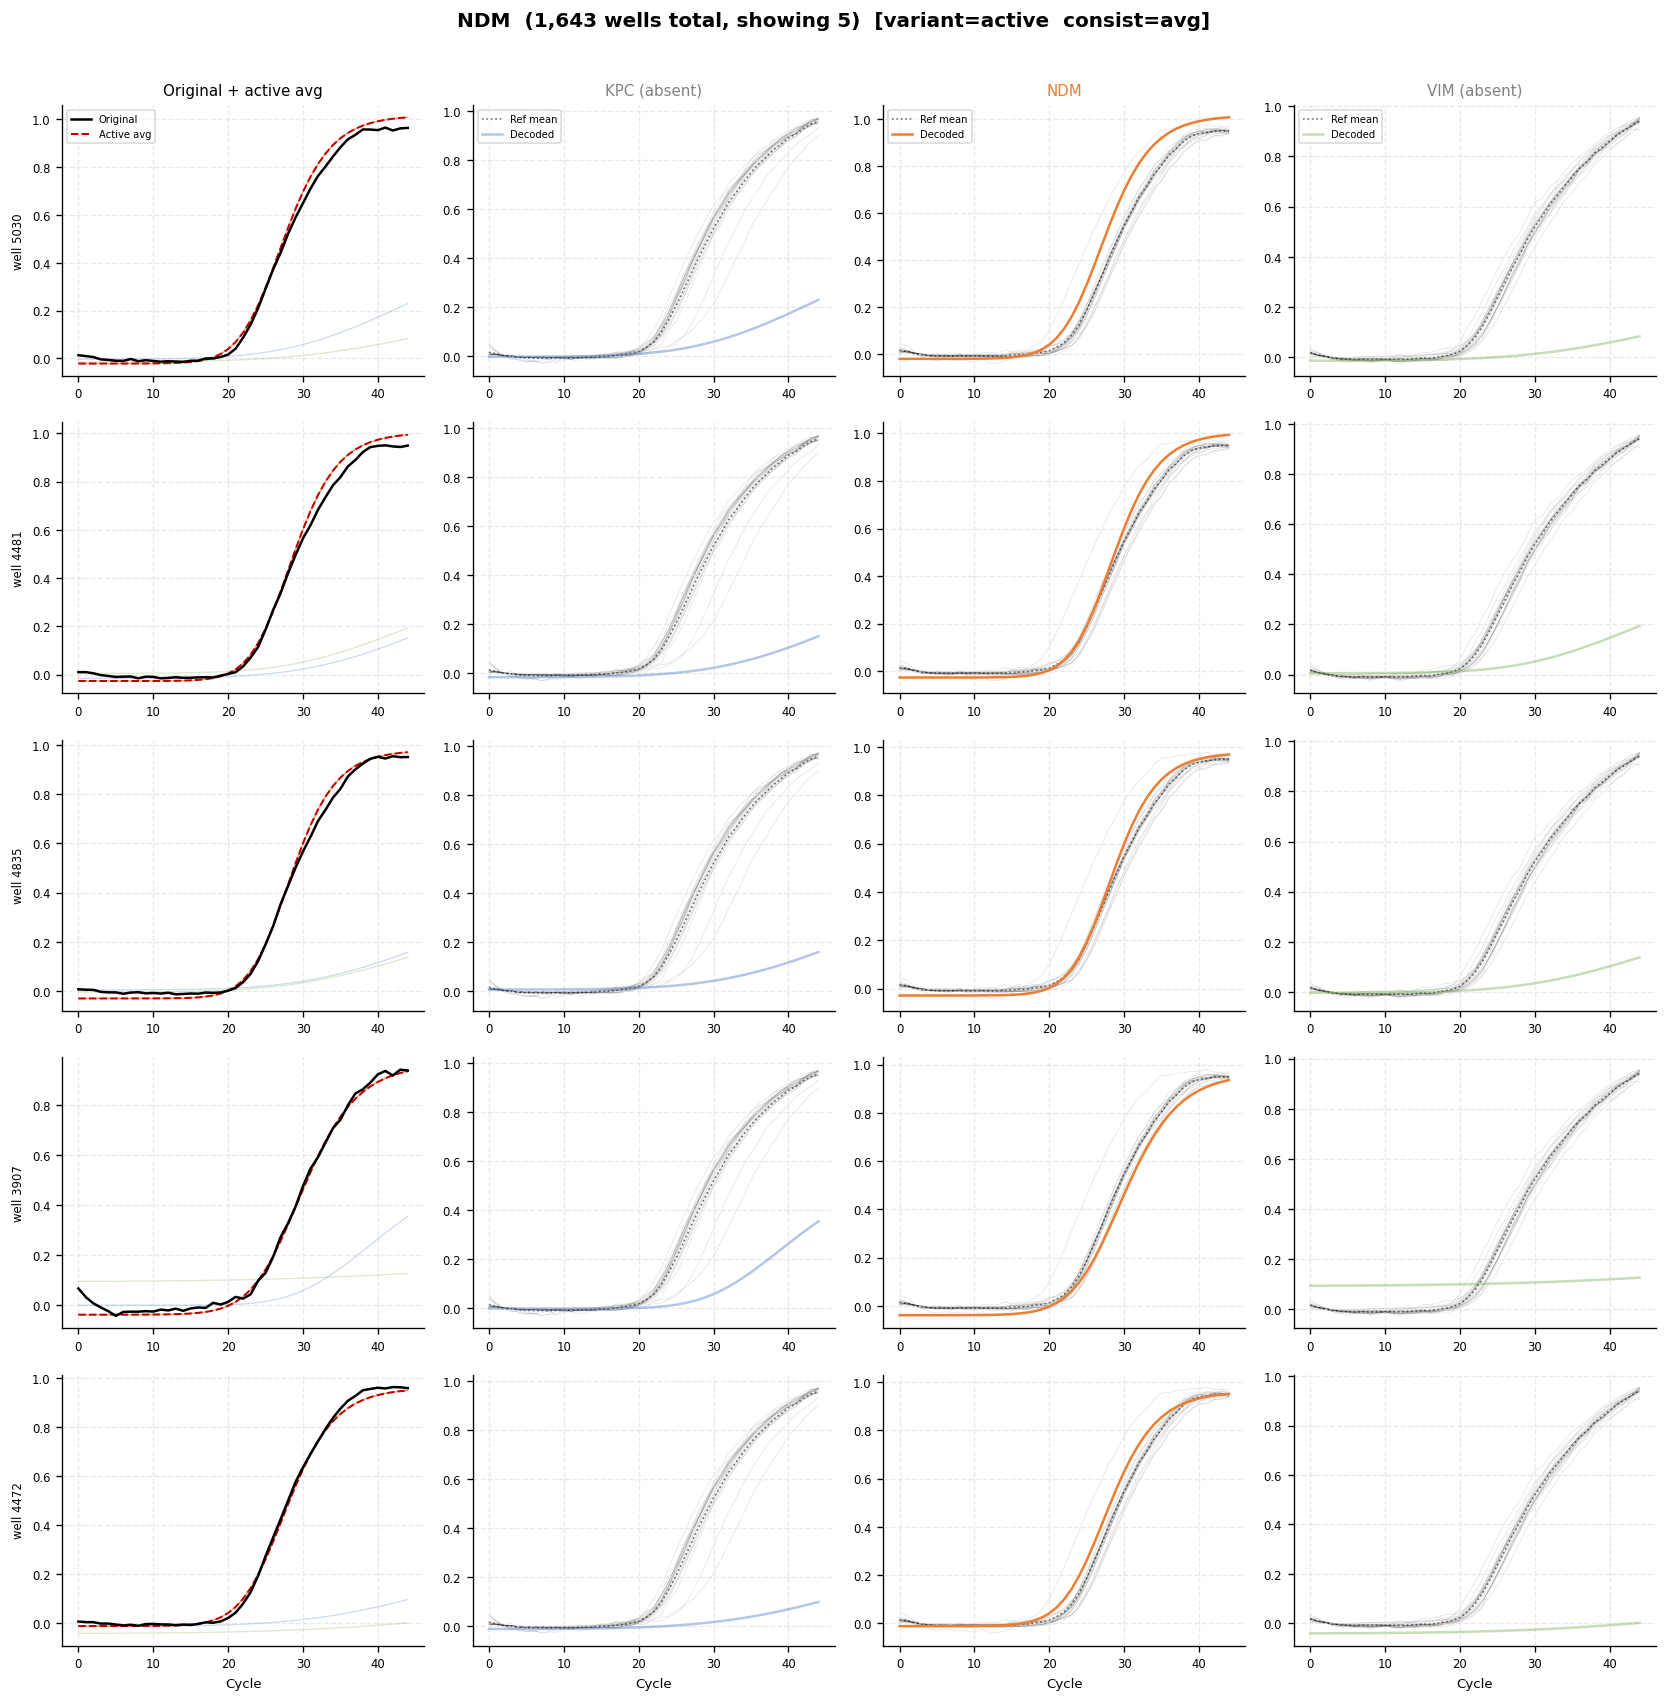

In [17]:
plot_combo([0, 1, 0])

### VIM only

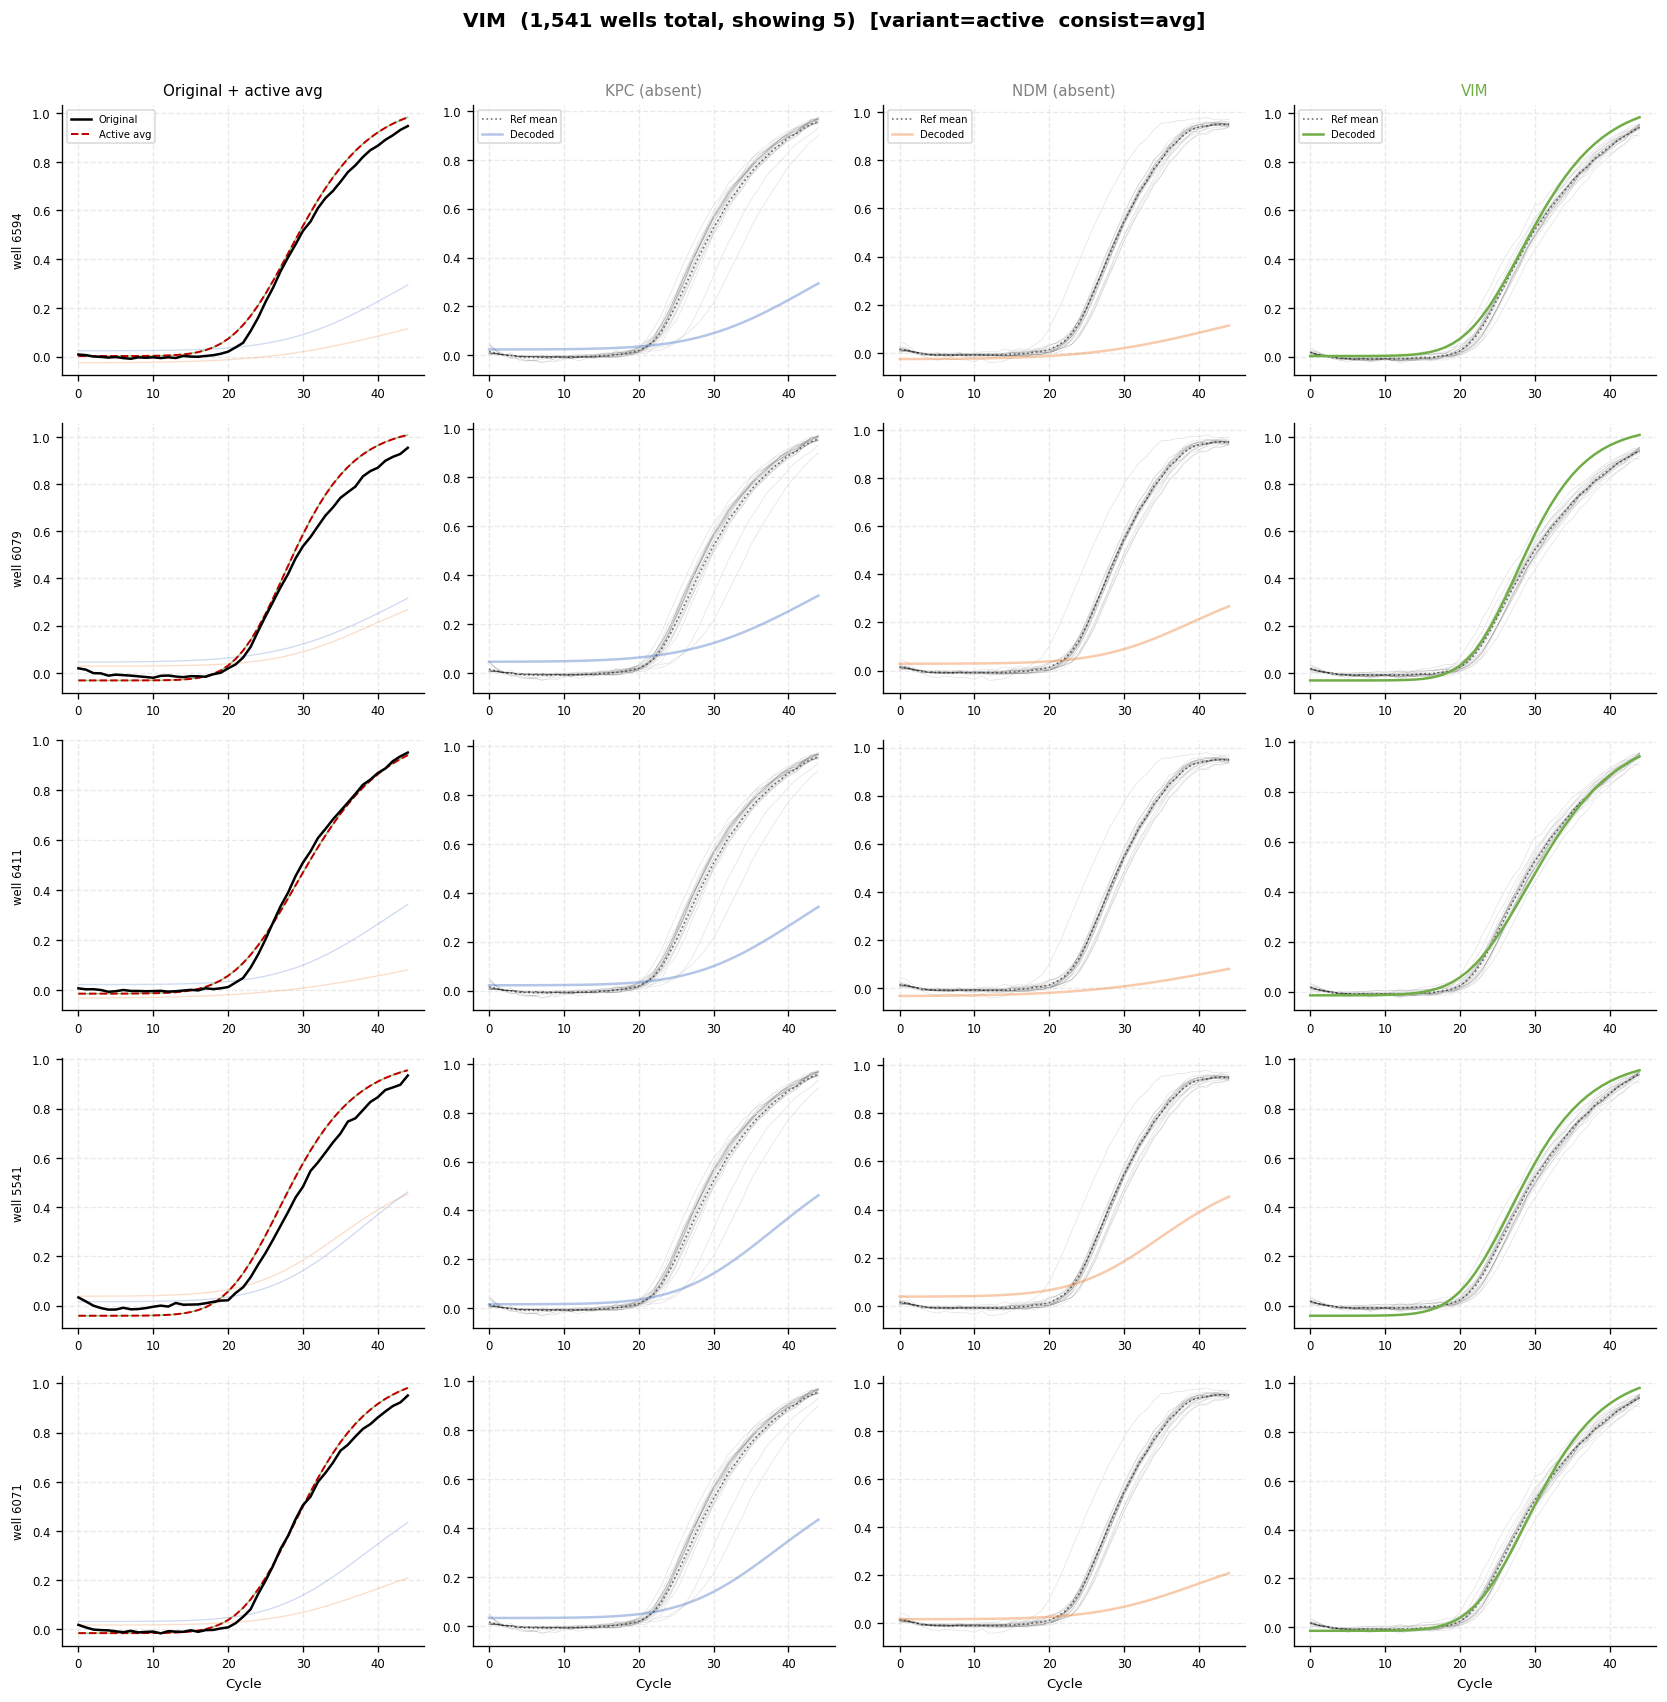

In [18]:
plot_combo([0, 0, 1])

### KPC + NDM

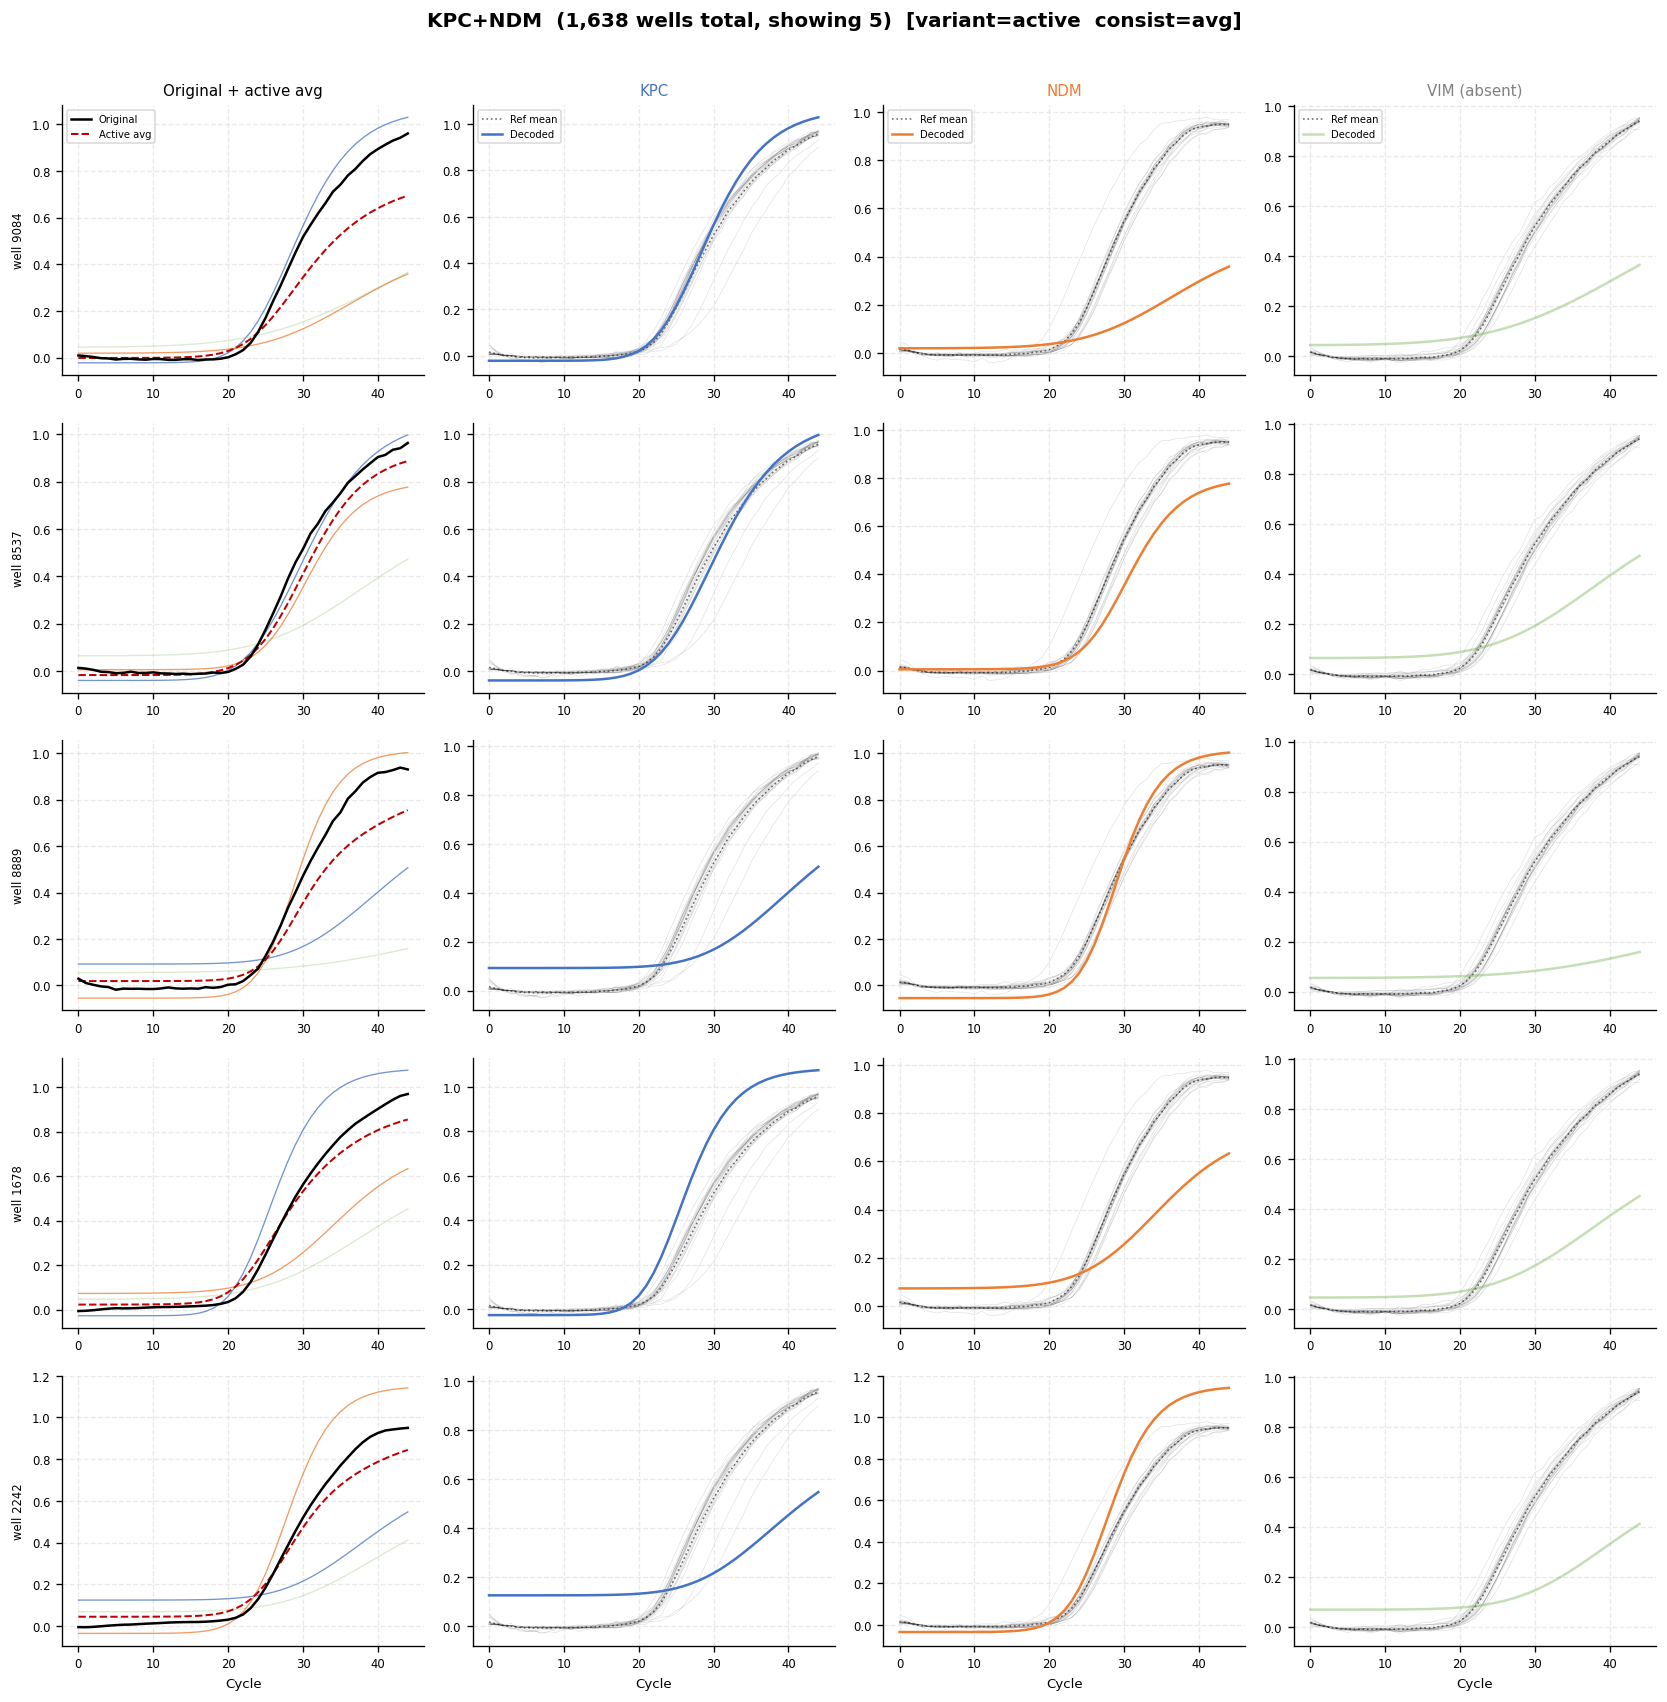

In [19]:
plot_combo([1, 1, 0])

### KPC + VIM

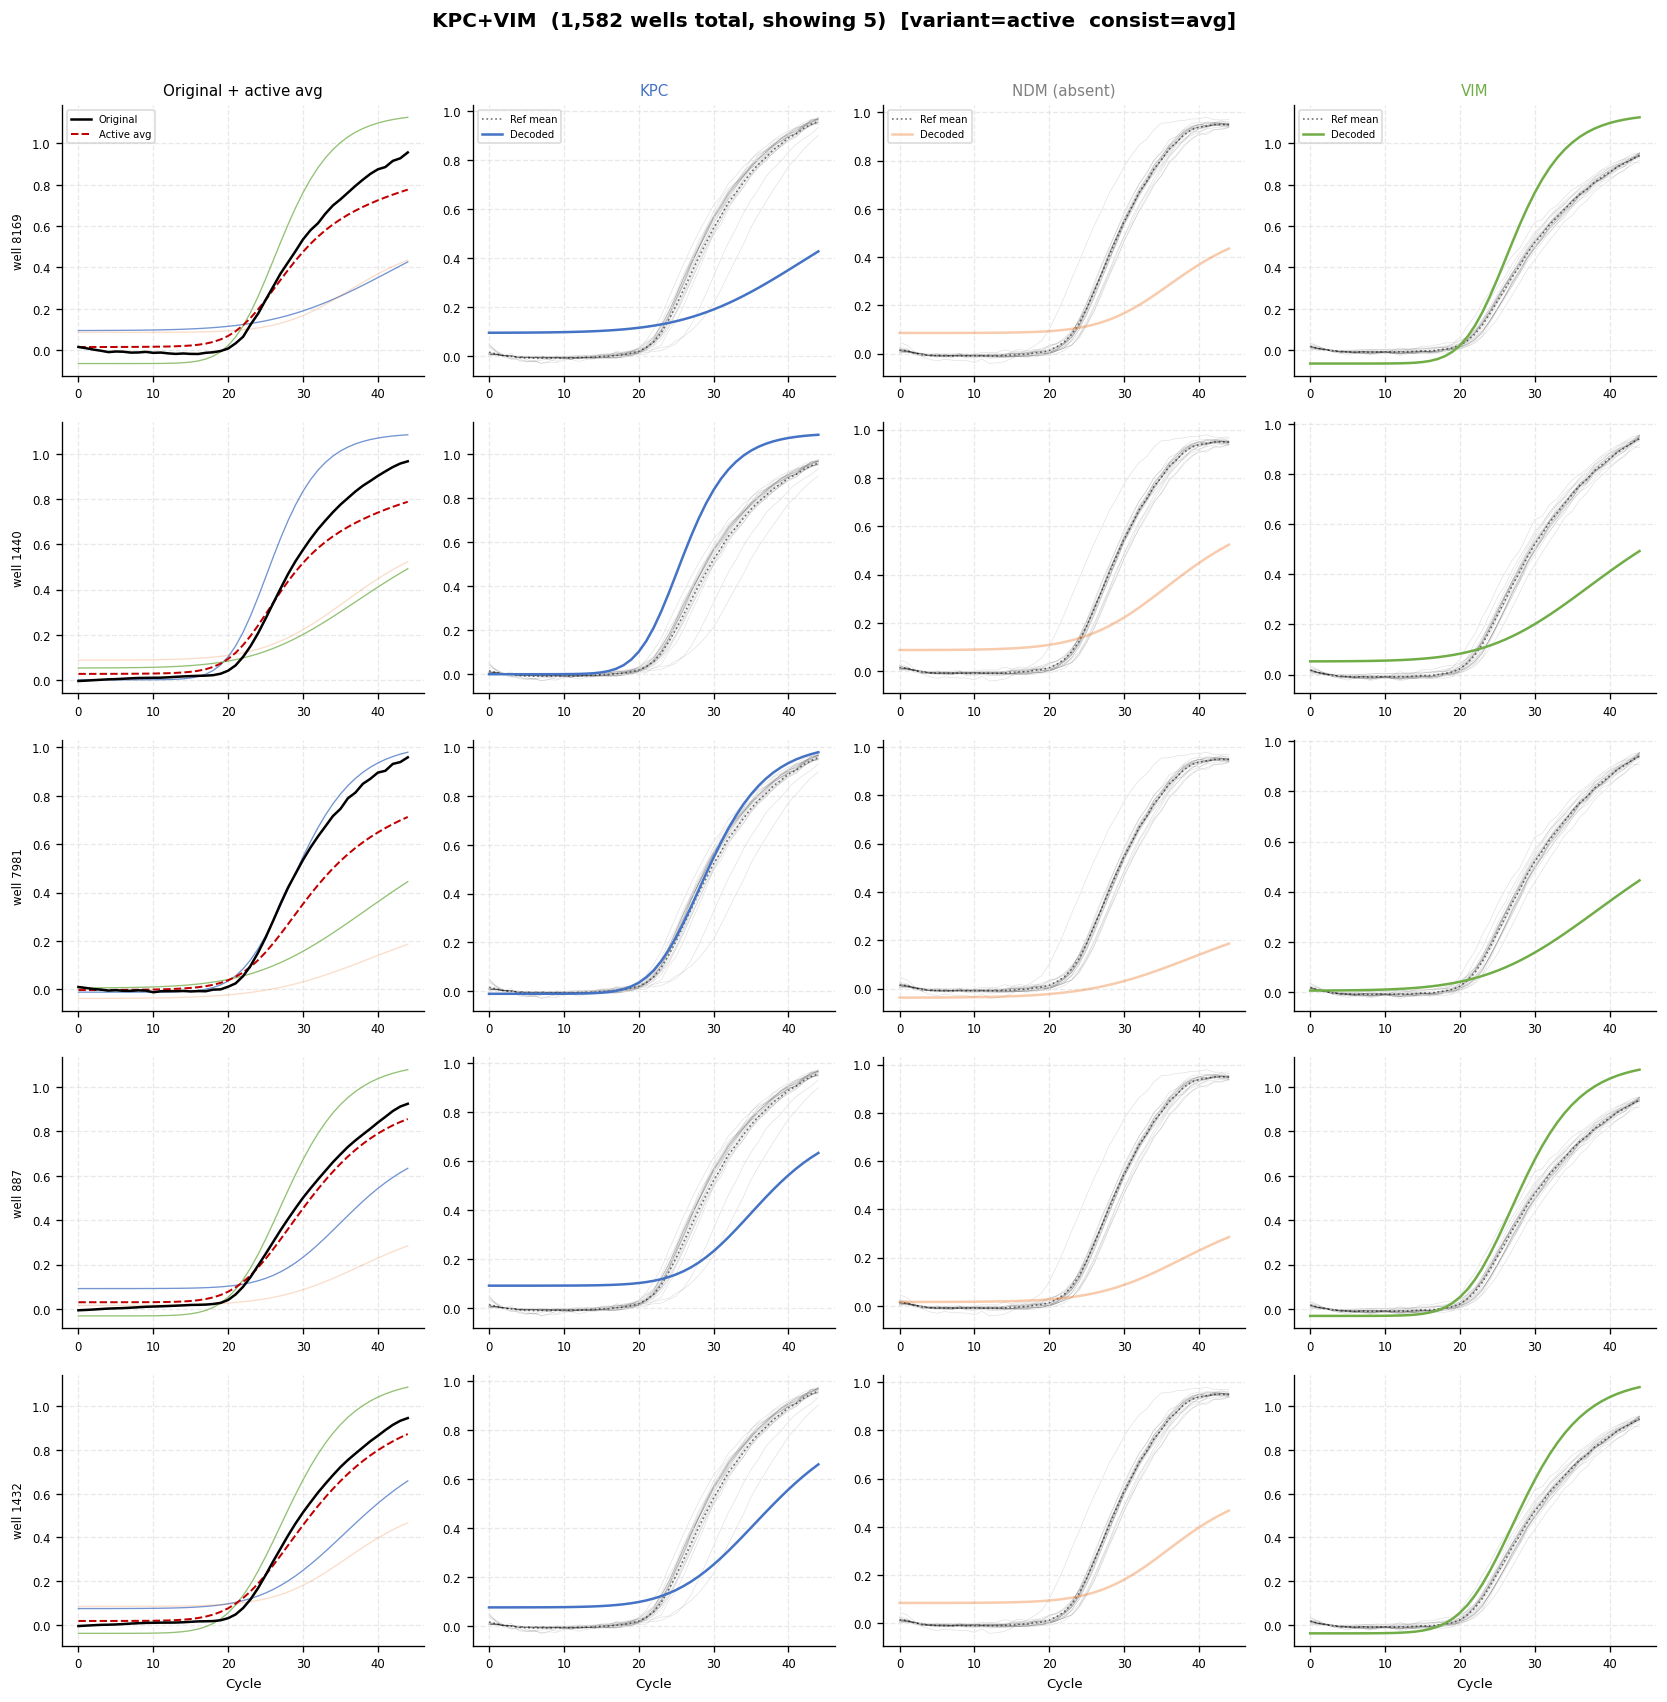

In [20]:
plot_combo([1, 0, 1])

### NDM + VIM

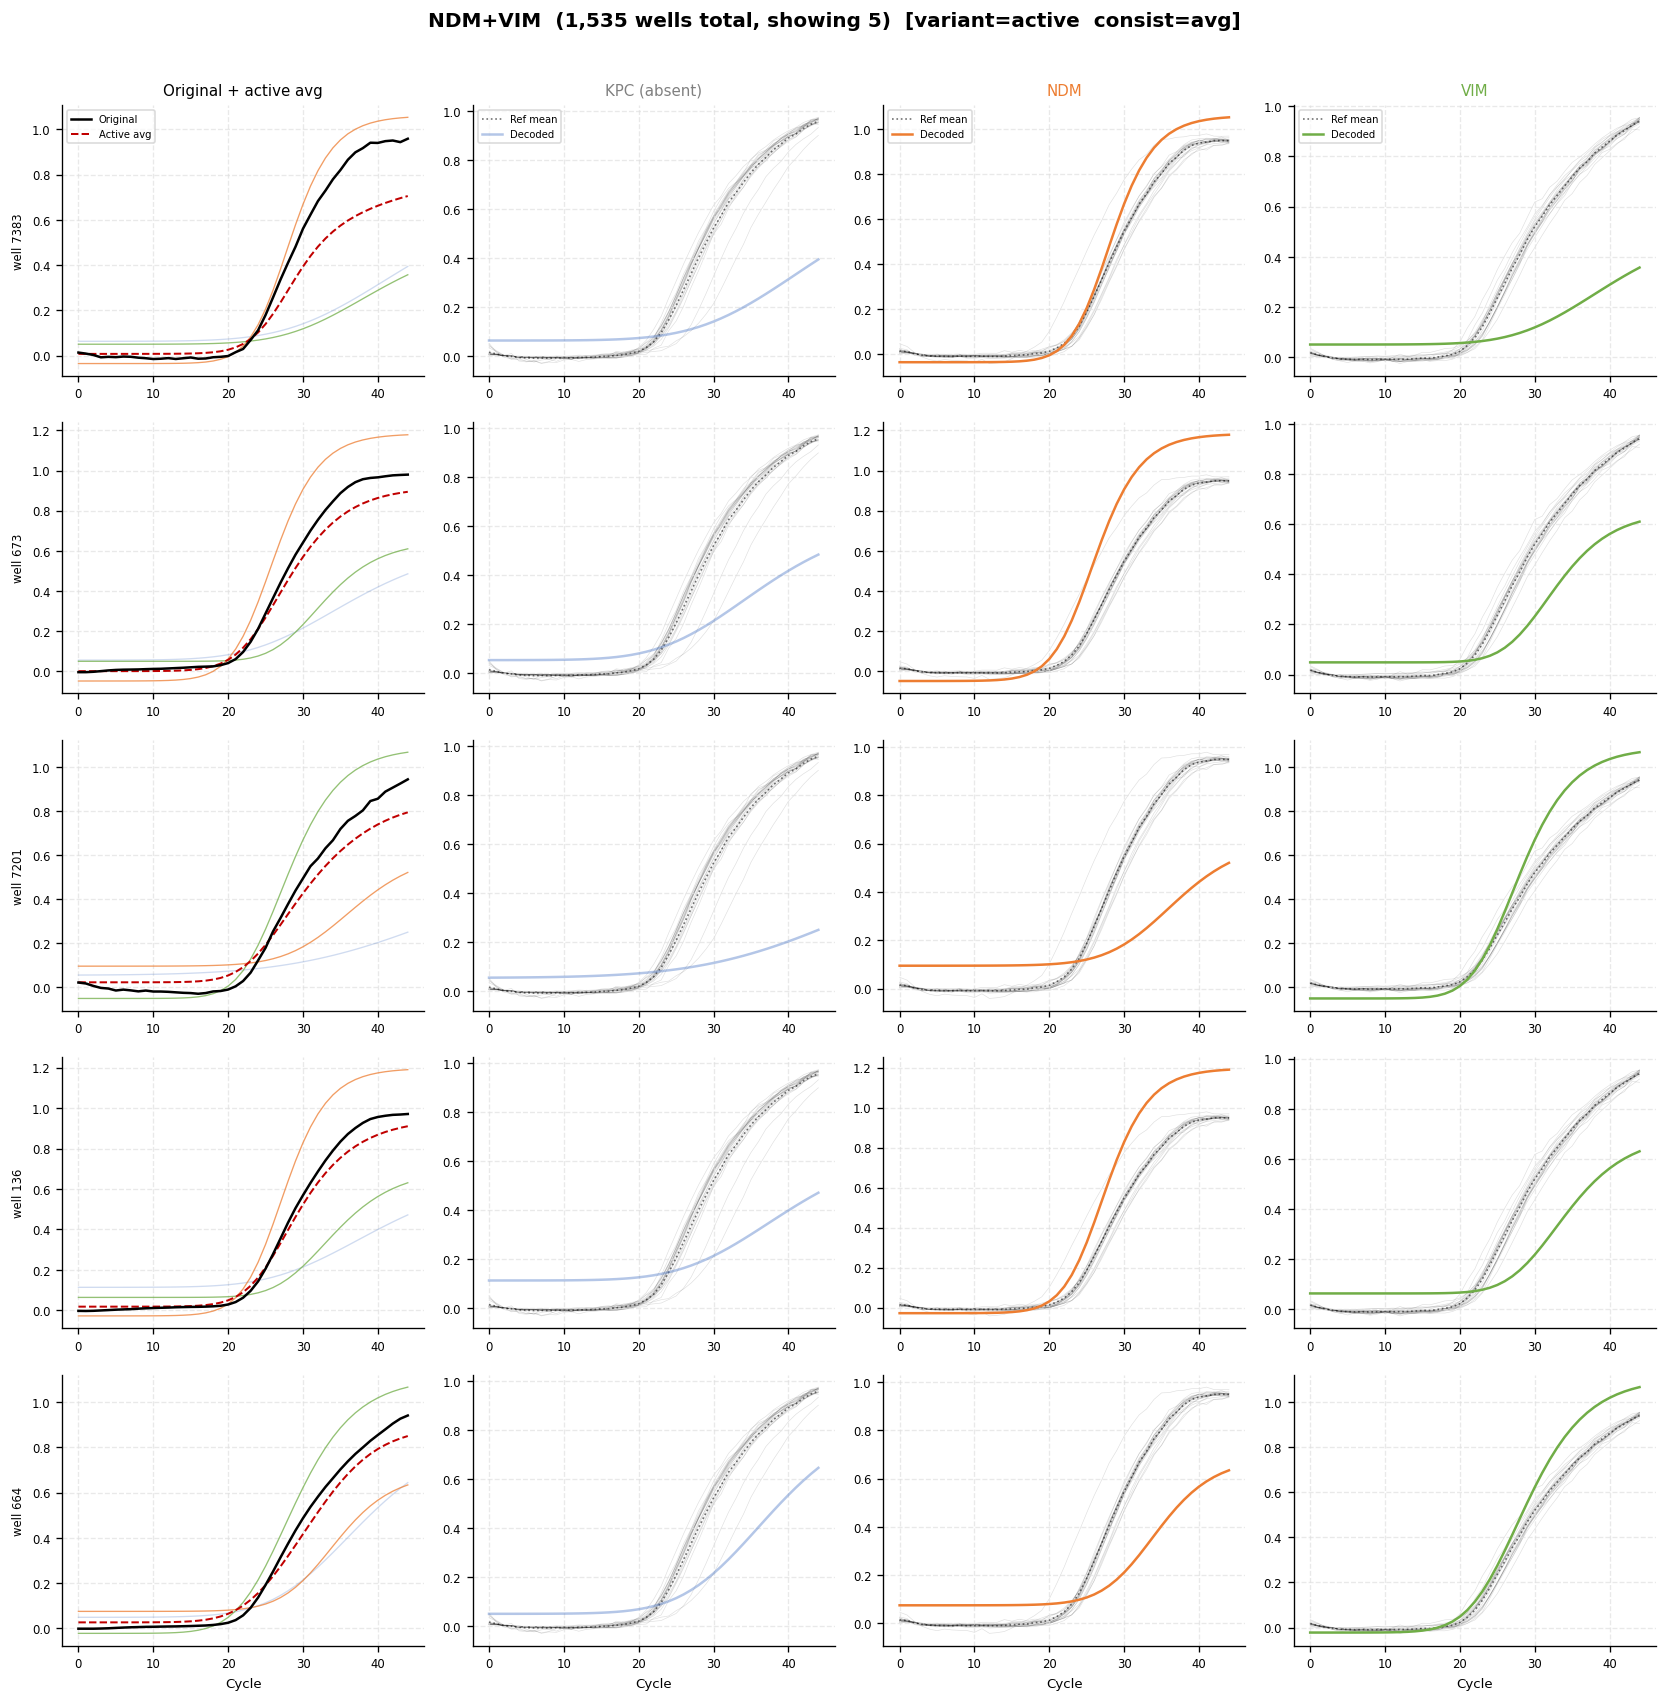

In [21]:
plot_combo([0, 1, 1])

### KPC + NDM + VIM

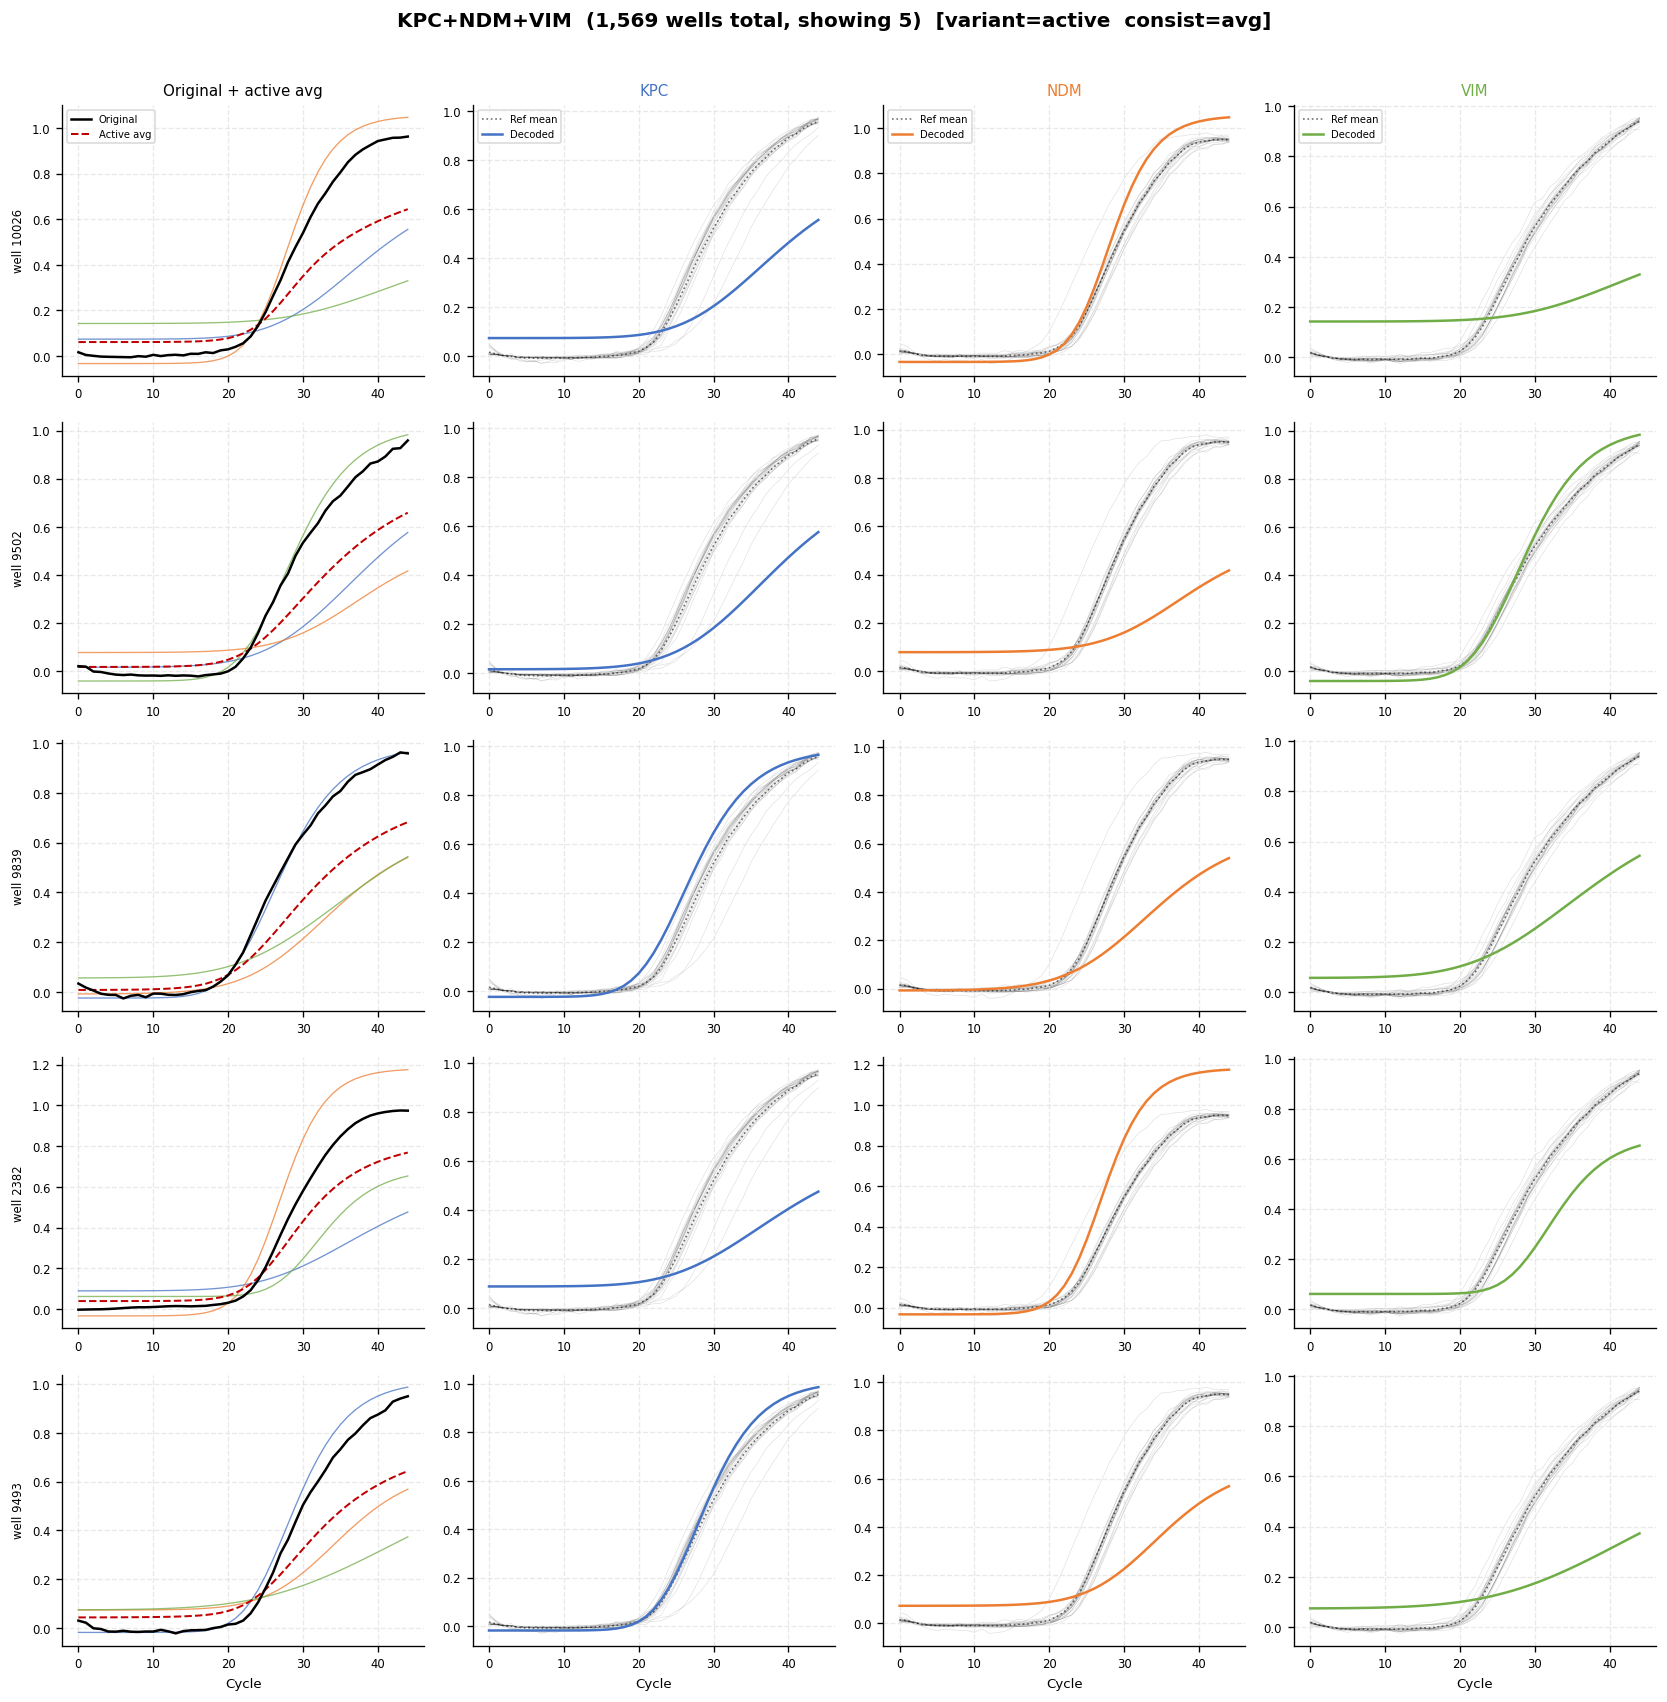

In [22]:
plot_combo([1, 1, 1])